# RescueTwin AI - Análisis Exploratorio de Datos

Este notebook realiza el análisis exploratorio del dataset integrado `rescuetwin_dataset.csv`.

El objetivo es entender el comportamiento de las variables del gemelo digital del robot cuadrúpedo y analizar qué factores se relacionan con el nivel de riesgo operativo en zonas de derrumbe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/processed/rescuetwin_dataset.csv")

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (2000, 24)


,zona,temperatura,humedad,presion,luz,sonido_db,co2,particulas_pm25,gas_tipo,gas_ppm,...,senal_comunicacion,bateria,voltaje_bateria,temperatura_bateria,autonomia_estimada_min,visibilidad,persona_detectada,confianza_persona,nivel_riesgo,accion_recomendada
0,Punto crítico,23.742562,37.156921,951.246360,0.59255,54.215643,505.075257,136.682603,gas_desconocido,16.081237,...,51.8,36.395081,10.82,4,28.5,45.2,0,0.11,Alto,Cambiar ruta o detenerse
1,Punto crítico,22.381415,37.422549,900.000000,0.00000,70.790609,545.730161,168.990470,humo,447.921945,...,58.6,61.886486,12.10,24,45.9,28.5,0,0.05,Alto,Cambiar ruta o detenerse
2,Túnel estrecho,22.333412,19.738998,941.234135,0.00000,50.419725,2085.626242,20.303590,sin_gas,326.041341,...,33.5,51.792509,11.46,24,37.8,72.8,0,0.14,Alto,Cambiar ruta o detenerse
3,Túnel estrecho,21.993103,40.284164,938.066586,0.53330,18.377416,2098.968669,102.632636,amoniaco,368.769094,...,23.5,60.061447,11.91,4,47.4,54.9,0,0.12,Alto,Cambiar ruta o detenerse
4,Habitación bloqueada,24.145010,42.892223,944.360592,0.47405,34.733886,915.139906,49.429148,sin_gas,1.303732,...,35.1,33.434138,11.06,24,23.1,74.9,0,0.19,Medio,Avanzar con precaución


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   zona                    2000 non-null   object 
 1   temperatura             2000 non-null   float64
 2   humedad                 2000 non-null   float64
 3   presion                 2000 non-null   float64
 4   luz                     2000 non-null   float64
 5   sonido_db               2000 non-null   float64
 6   co2                     2000 non-null   float64
 7   particulas_pm25         2000 non-null   float64
 8   gas_tipo                2000 non-null   object 
 9   gas_ppm                 2000 non-null   float64
 10  vibracion               2000 non-null   float64
 11  inclinacion             2000 non-null   float64
 12  distancia_obstaculo     2000 non-null   float64
 13  velocidad_robot         2000 non-null   float64
 14  senal_comunicacion      2000 non-null   

In [4]:
df.describe()

,temperatura,humedad,presion,luz,sonido_db,co2,particulas_pm25,gas_ppm,vibracion,inclinacion,distancia_obstaculo,velocidad_robot,senal_comunicacion,bateria,voltaje_bateria,temperatura_bateria,autonomia_estimada_min,visibilidad,persona_detectada,confianza_persona
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,22.066611,33.262511,931.324131,1.197809,33.679281,1435.710787,93.113170,251.245815,1.278715,17.473650,2.565915,0.782260,60.265750,58.882279,11.739900,19.958500,44.083150,54.151150,0.170500,0.304200
std,2.044869,7.926508,22.219832,5.321829,17.794980,608.041380,50.060173,143.838402,0.719571,9.968788,1.377565,0.397121,23.421764,11.052257,0.282448,11.063317,8.953788,15.727204,0.376166,0.249815
min,13.632610,13.848169,900.000000,0.000000,3.399427,400.388910,5.020763,0.120335,0.000000,0.000000,0.200000,0.100000,20.000000,15.000000,10.500000,4.000000,5.400000,13.100000,0.000000,0.010000
25%,20.643200,26.628829,900.000000,0.000000,20.426184,930.772529,50.526273,127.470834,0.660000,9.000000,1.360000,0.440000,39.700000,60.061447,11.630000,4.000000,44.400000,42.600000,0.000000,0.130000
50%,22.182346,34.755090,943.522421,0.000000,29.728107,1429.161414,93.813686,251.471846,1.270000,17.550000,2.600000,0.770000,59.900000,60.061447,11.770000,24.000000,44.400000,54.400000,0.000000,0.240000
75%,23.674634,38.904536,948.546536,0.533300,42.672035,1947.521880,136.500762,371.836652,1.902500,25.700000,3.720000,1.120000,81.200000,60.061447,11.900000,24.000000,47.400000,65.600000,0.000000,0.370000
max,28.218289,50.293425,960.055426,100.000000,76.791244,2499.234813,179.840884,499.946333,2.500000,35.000000,5.000000,1.500000,100.000000,100.000000,12.600000,44.000000,76.400000,94.100000,1.000000,0.980000


In [5]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nCantidad de duplicados:")
print(df.duplicated().sum())

Valores nulos por columna:
zona                      0
temperatura               0
humedad                   0
presion                   0
luz                       0
sonido_db                 0
co2                       0
particulas_pm25           0
gas_tipo                  0
gas_ppm                   0
vibracion                 0
inclinacion               0
distancia_obstaculo       0
velocidad_robot           0
senal_comunicacion        0
bateria                   0
voltaje_bateria           0
temperatura_bateria       0
autonomia_estimada_min    0
visibilidad               0
persona_detectada         0
confianza_persona         0
nivel_riesgo              0
accion_recomendada        0
dtype: int64

Cantidad de duplicados:
0


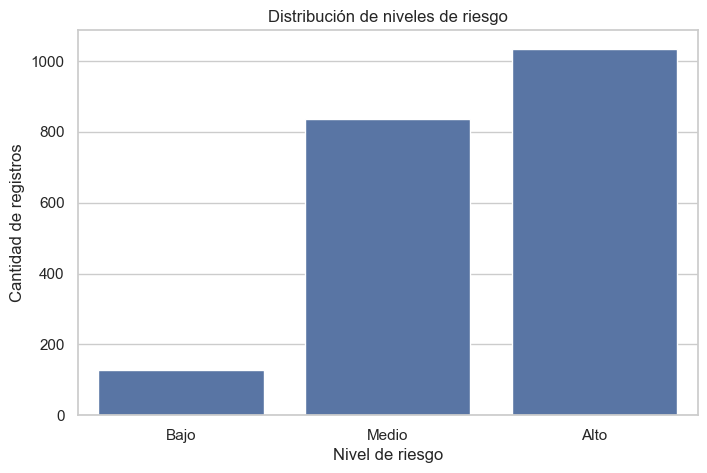

In [6]:
df["nivel_riesgo"].value_counts()
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="nivel_riesgo", order=["Bajo", "Medio", "Alto"])
plt.title("Distribución de niveles de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de registros")
plt.show()

La distribución de la variable objetivo permite observar cuántos casos fueron clasificados como riesgo bajo, medio y alto. Esto es importante porque el modelo debe aprender a distinguir correctamente las tres clases, especialmente los casos de riesgo alto.

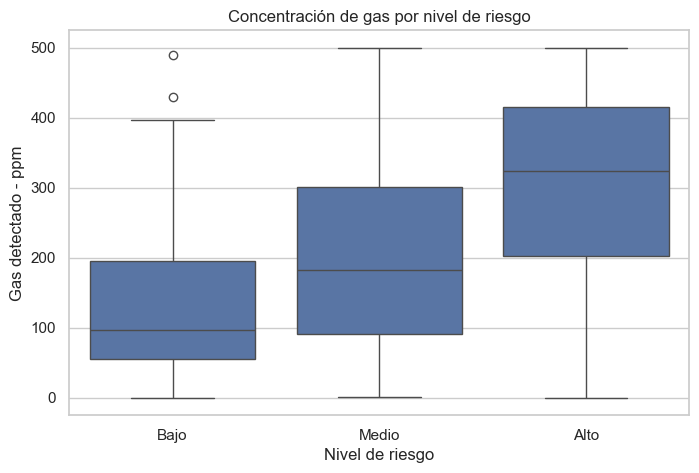

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="nivel_riesgo", y="gas_ppm", order=["Bajo", "Medio", "Alto"])
plt.title("Concentración de gas por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Gas detectado - ppm")
plt.show()

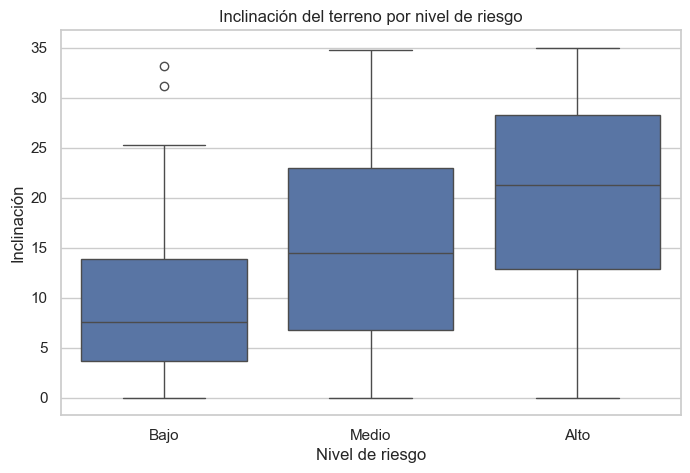

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="nivel_riesgo", y="inclinacion", order=["Bajo", "Medio", "Alto"])
plt.title("Inclinación del terreno por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Inclinación")
plt.show()

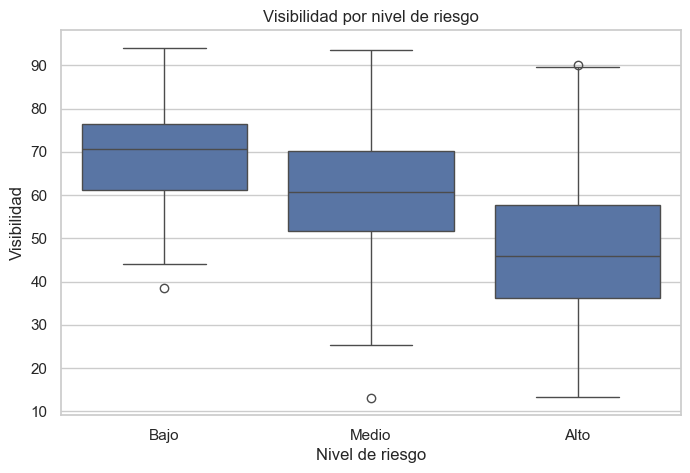

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="nivel_riesgo", y="visibilidad", order=["Bajo", "Medio", "Alto"])
plt.title("Visibilidad por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Visibilidad")
plt.show()

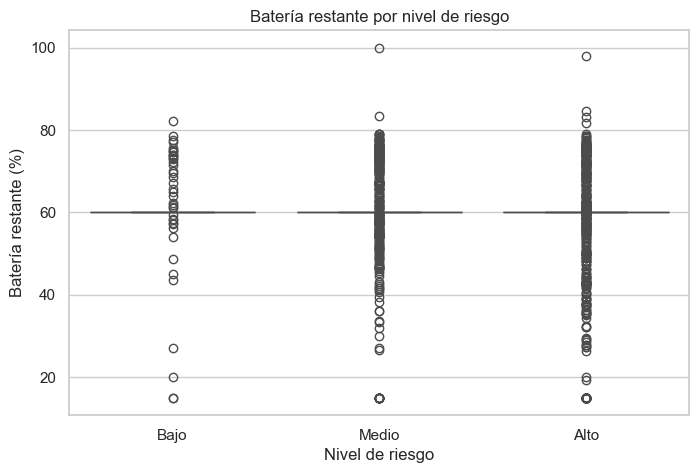

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="nivel_riesgo", y="bateria", order=["Bajo", "Medio", "Alto"])
plt.title("Batería restante por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Batería restante (%)")
plt.show()

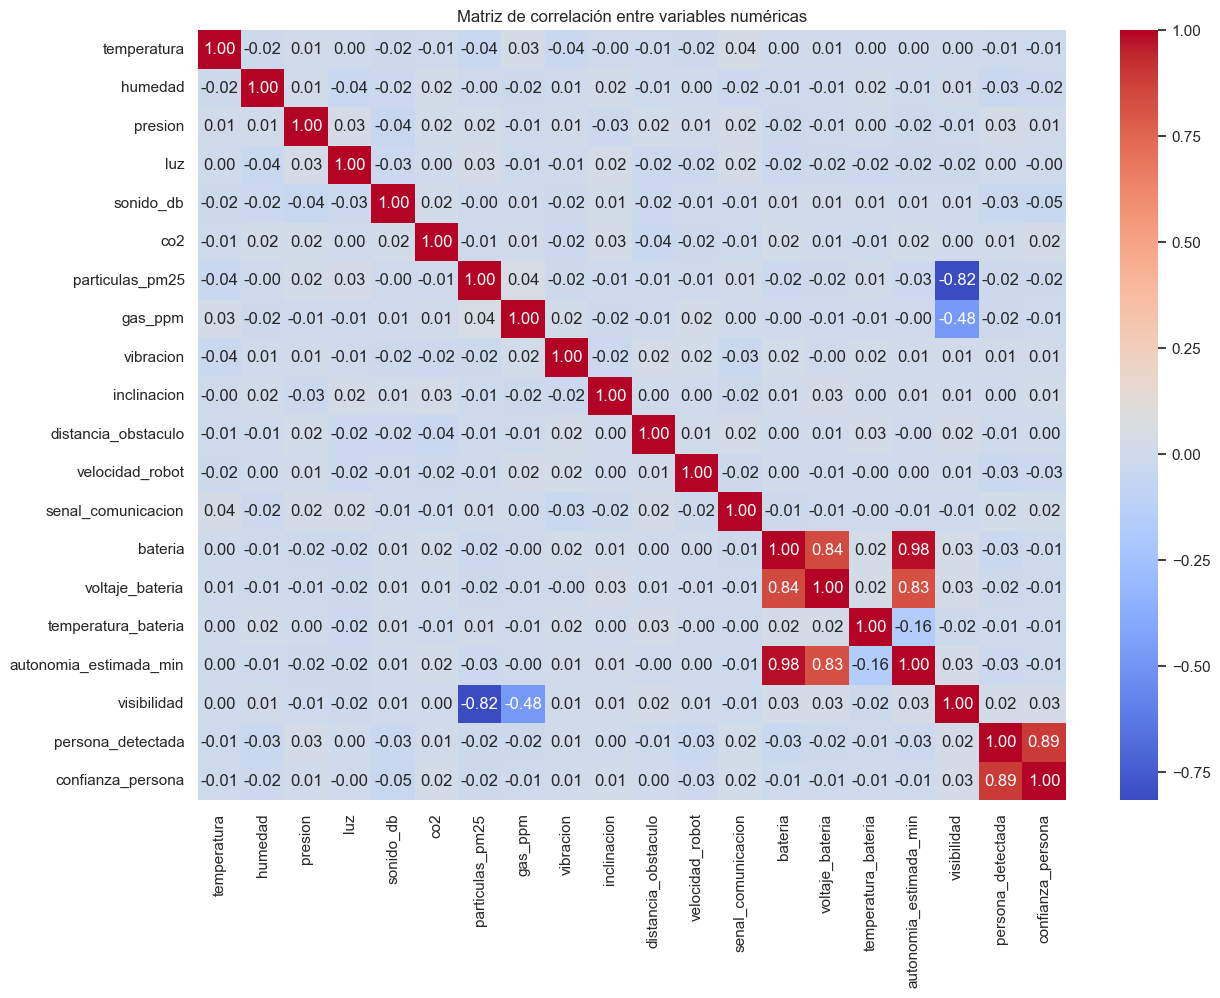

In [11]:
plt.figure(figsize=(14,10))

correlacion = df.corr(numeric_only=True)

sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

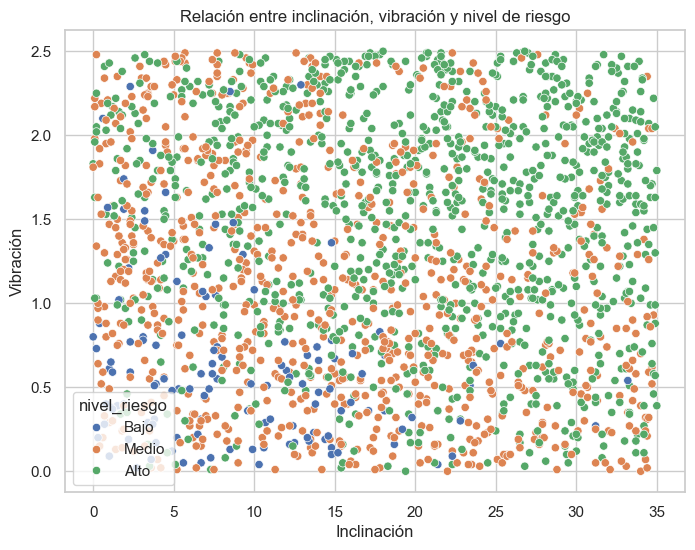

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="inclinacion",
    y="vibracion",
    hue="nivel_riesgo",
    hue_order=["Bajo", "Medio", "Alto"]
)
plt.title("Relación entre inclinación, vibración y nivel de riesgo")
plt.xlabel("Inclinación")
plt.ylabel("Vibración")
plt.show()

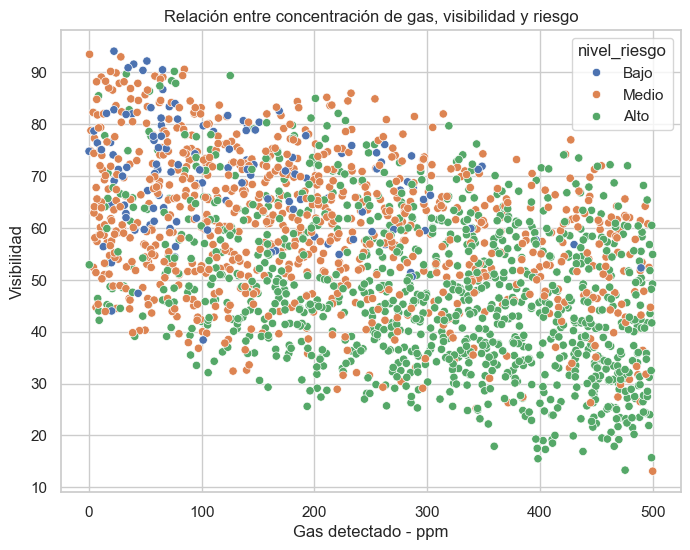

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="gas_ppm",
    y="visibilidad",
    hue="nivel_riesgo",
    hue_order=["Bajo", "Medio", "Alto"]
)
plt.title("Relación entre concentración de gas, visibilidad y riesgo")
plt.xlabel("Gas detectado - ppm")
plt.ylabel("Visibilidad")
plt.show()

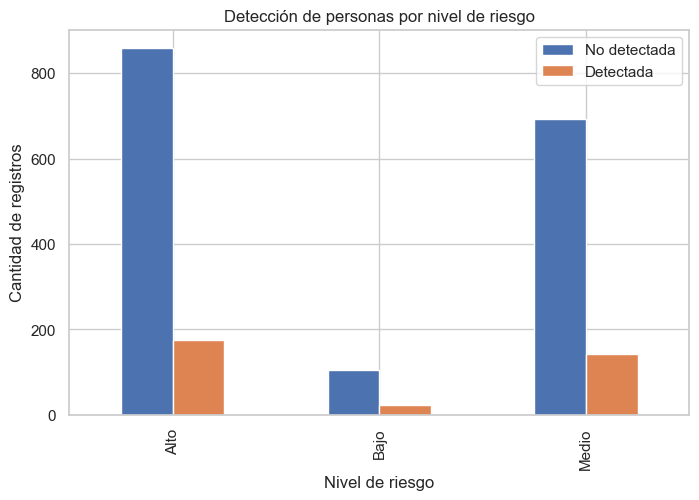

In [14]:
tabla_personas = pd.crosstab(df["nivel_riesgo"], df["persona_detectada"])
tabla_personas
tabla_personas.plot(kind="bar", figsize=(8,5))
plt.title("Detección de personas por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de registros")
plt.legend(["No detectada", "Detectada"])
plt.show()

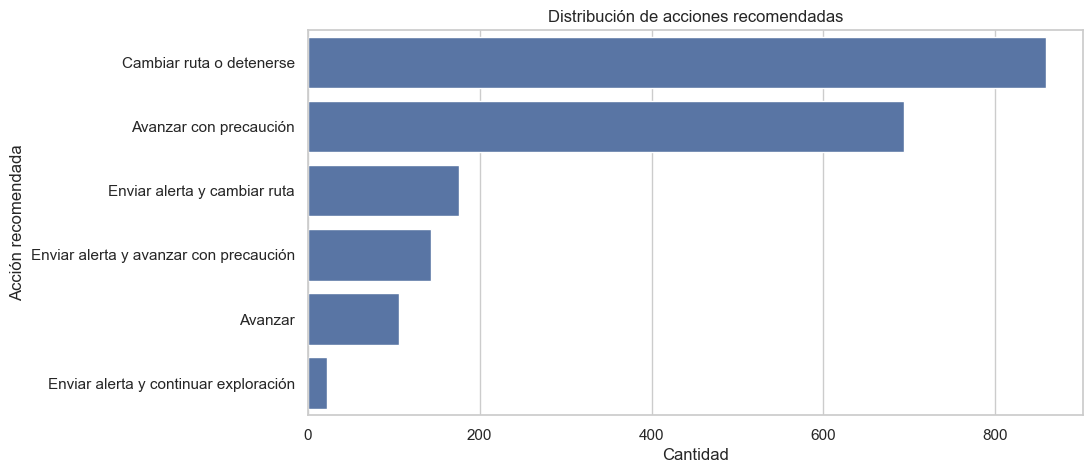

In [15]:
df["accion_recomendada"].value_counts()
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="accion_recomendada", order=df["accion_recomendada"].value_counts().index)
plt.title("Distribución de acciones recomendadas")
plt.xlabel("Cantidad")
plt.ylabel("Acción recomendada")
plt.show()

## Conclusiones del análisis exploratorio

1. Las zonas con riesgo alto tienden a presentar mayores niveles de gas, vibración e inclinación, lo cual representa condiciones peligrosas para el avance del robot.

2. La visibilidad disminuye en escenarios con mayor concentración de partículas y gases, afectando la capacidad de navegación del robot dentro del derrumbe.

3. La batería no siempre define el riesgo ambiental de una zona, pero sí influye en la acción operativa recomendada, ya que una batería baja puede limitar la autonomía del robot.

4. La detección de personas no necesariamente aumenta el nivel de riesgo, pero modifica la acción recomendada, priorizando el envío de alertas al equipo de rescate.

5. El análisis exploratorio permite identificar que el riesgo operativo depende de una combinación de variables ambientales, estructurales y operativas, justificando el uso de un modelo de clasificación.

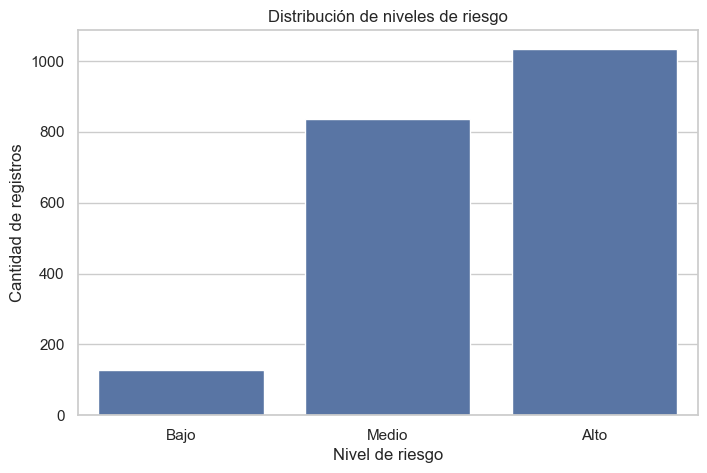

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="nivel_riesgo", order=["Bajo", "Medio", "Alto"])
plt.title("Distribución de niveles de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de registros")
plt.savefig("../reports/graficos/distribucion_riesgo.png", bbox_inches="tight")
plt.show()